In [1]:
from pathlib import Path
import json
import numpy as np
# from sklearn.manifold import TSNE
import pandas as pd
from PIL import Image
arrays = sorted(Path("outputs").glob("*.json"))

classes = ('flow_diagram', 'scatterplot', 'bar_chart', 'graph', 'treemap', 'table', 'line_chart', 'tree', 'small_multiple', 'heatmap', 'matrix', 'map', 'pie_chart', 'sankey_diagram', 'area_chart', 'proportional_area_chart', 'glyph_based', 'stripe_graph', 'parallel_coordinate', 'sunburst_icicle', 'unit_visualization', 'polar_plot', 'error_bar', 'box_plot', 'sector_chart', 'word_cloud', 'donut_chart', 'hierarchical_edge_bundling', 'chord_diagram', 'storyline')

print(arrays[0])
fname = arrays[0]
# testing with specific multi plot values
fname = Path("outputs/array_fig-2340671844-Figure50-1.json")
figure_name = f"{fname.parent}/{fname.stem.split('_')[1]}.png"
print(figure_name)
figure_vectors = []
for fname in arrays:
    json_data = json.loads(Path(fname).read_text())
    arr_data = np.array(json_data)
#     print(arr_data)
    temp_res = []
    for r in arr_data:
      # handle case where the len is 0:
      if len(r) ==0:
        temp_res.append(np.zeros((1,5)))
      elif len(r) ==1:
        temp_res.append(np.array(r))
      elif len(r) >1:
        # find the one that has the max
        r = np.array(r)
        max_row = np.argmax(r[:,-1])
        # the none here helps maintaing the 1,5 shape that the rest of the code expects, without it we drop to single dimensional array
        temp_res.append(r[None,max_row])
    arr_data = np.array(temp_res)
#     print(arr_data)
#     print(len(arr_data))
#     [print("part",e.shape) for e in arr_data]
#     print(classes)
#     print(len(classes))
    # padd the arr_datas
    bboxes = np.vstack(arr_data)
#     print(bboxes.shape)
    scores = bboxes[:,-1]
#     print("these are the scores",scores)
#     print([(s,c) for s,c in zip(scores,classes)])
    figure_vectors.append(scores)

figure_vectors = np.array(figure_vectors)

df = pd.DataFrame(figure_vectors,columns=classes)
df

outputs/array_fig-2340671844-Figure1-1.json
outputs/fig-2340671844-Figure50-1.png


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:20: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray


,flow_diagram,scatterplot,bar_chart,graph,treemap,table,line_chart,tree,small_multiple,heatmap,...,unit_visualization,polar_plot,error_bar,box_plot,sector_chart,word_cloud,donut_chart,hierarchical_edge_bundling,chord_diagram,storyline
0,0.000000,0.000000,0.085615,0.000000,0.064134,0.000000,0.000000,0.115306,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.212718,0.0,0.130107,0.0
1,0.277645,0.000000,0.000000,0.977974,0.000000,0.000000,0.000000,0.074973,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2,0.722258,0.130578,0.095444,0.315893,0.086076,0.207352,0.000000,0.159914,0.0,0.071903,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
3,0.000000,0.141790,0.114307,0.199752,0.785953,0.000000,0.000000,0.286843,0.0,0.077759,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
4,0.000000,0.000000,0.000000,0.728616,0.000000,0.000000,0.058152,0.232782,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.000000,0.785818,0.223899,0.000000,0.000000,0.000000,0.180294,0.061117,0.0,0.198362,...,0.057743,0.0,0.089125,0.0,0.086109,0.0,0.347469,0.0,0.121058,0.0
9996,0.000000,0.323135,0.000000,0.000000,0.000000,0.000000,0.730704,0.000000,0.0,0.000000,...,0.000000,0.0,0.411171,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
9997,0.000000,0.325408,0.280870,0.000000,0.000000,0.000000,0.156968,0.000000,0.0,0.195585,...,0.000000,0.0,0.193977,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
9998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.973479,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0


In [3]:
df.to_csv("zhiyang_material/chart_type_10k_inferences.csv")

In [4]:
#demo code for the tsne
# anything below this and we zero it out
threshold = .25
figure_vectors[figure_vectors < .25] =0
# perplexity value, not sure what this is but it really changes the embeddings
p = 15

embedding = TSNE(n_components =2,learning_rate="auto",init="random",perplexity=p).fit_transform(figure_vectors)


np.save(f"embedded_chart_types_{p}_{2}d.npy",embedding)



for c in classes:
    print(df[c].describe())
    print()

# function to put together a bunch of the candidate images that belong to a particular column
# goal is to order it by higher probabilities
# then take the top 100 if there are that many and stack them into a large image which we can display


total = 100
dim = 256
def check_top_type(chart_type,total,dim):
    top = df[chart_type].sort_values(ascending=False)[:total]
    inds = top.index

   
    per_side = int(total**.5)+1
    new_image = Image.new("RGB",(dim*per_side,dim*per_side),)

    # now we iterate over the tiles and read in the image and downsize and paste it into the collage
    x=0
    y=0
    for i,ind in enumerate(inds):
        y=(i)//per_side
        x=(i)%per_side

        array_fname = arrays[ind]
        image_name = Path(f"{array_fname.parent}/result_{array_fname.stem.split('_')[1]}.jpg")
        im = Image.open(str(image_name))
        small = im.resize((dim-10,dim-10))
        # paste it in
        new_image.paste(small,(x*dim+10,y*dim+10))
    
    print("type is",chart_type)
    return new_image

for c in classes:
    im = check_top_type(c,total,dim)
    im.save(f"top_{c}_images.png")

    
import matplotlib.pyplot as plt

import seaborn as sns
full_figure,axes = plt.subplots(5,6,figsize=(35,20))

# lets accentuate the bar chart locations
# order the columns by most entries positively scored
indices = (-1*df.sum()).argsort()
for i,ind in enumerate(indices):
    col=i%6
    row= i//6
    ax = axes[row,col]
    c = classes[ind]
    colors = df[c] > .9

    df_subset[f"is {c}"] = colors


    
    my_plot = sns.scatterplot(
        ax=ax,
        x="x", y="y", hue=f"is {c}",
        data=df_subset,
        s=2,
        legend="full",
        alpha=0.3
    )
#     my_plot.set(title=f"{c} neighborhood")
#     my_plot.get_figure().savefig(f"{c}_neighborhood.png")
full_figure

outputs/array_fig-2340671844-Figure1-1.json
outputs/fig-2340671844-Figure50-1.png


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:20: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray


count    10000.000000
mean         0.059650
std          0.203600
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.995966
Name: flow_diagram, dtype: float64

count    10000.000000
mean         0.201968
std          0.331161
min          0.000000
25%          0.000000
50%          0.000000
75%          0.361764
max          0.994552
Name: scatterplot, dtype: float64

count    10000.000000
mean         0.142724
std          0.302673
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.999214
Name: bar_chart, dtype: float64

count    10000.000000
mean         0.086974
std          0.229251
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.997485
Name: graph, dtype: float64

count    10000.000000
mean         0.005737
std          0.055261
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      

ModuleNotFoundError: No module named 'seaborn'

In [23]:
df.scatterplot.sort_values(ascending=False)

4755    0.994552
462     0.993910
7002    0.993704
7972    0.993305
5937    0.993050
          ...   
4747    0.000000
4740    0.000000
4737    0.000000
4736    0.000000
9999    0.000000
Name: scatterplot, Length: 10000, dtype: float64

In [4]:
pip install duckdb

  Using cached duckdb-1.1.0-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (20.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
arrays[4755]

PosixPath('outputs/array_fig-4224452056-Figure2-1.json')

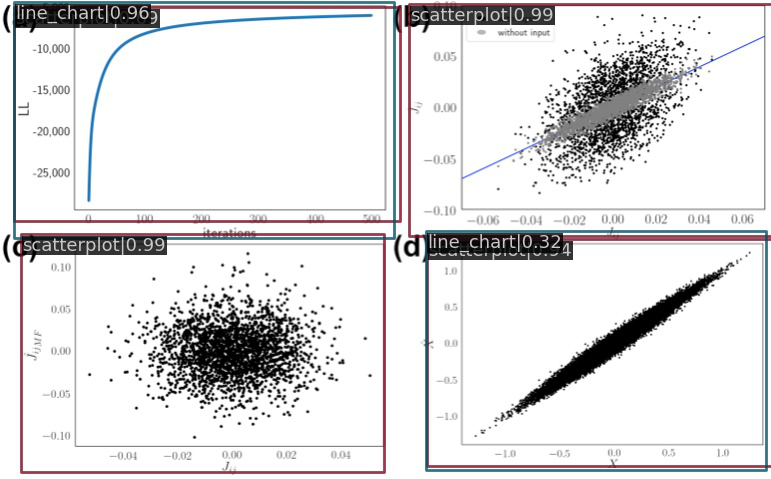

In [4]:
from PIL import Image
Image.open(str(f"outputs/result_{arrays[4755].stem.split('_')[1]}.jpg"))

In [ ]:
## IMPORTANT THIS IS WHERE WE SHOW HOW TO UPDATE A DUCKDB FILE WITH NEW DATA FOR FIGURE PROPERTIES

In [55]:
#if we are making new table for figures that duplicates the charts then how does it wokr with the other tables that are there?
import duckdb as db
con = db.connect("new_layout.db")

In [31]:
#con.close()

In [34]:
con.query("SHOW TABLES")

┌─────────────────┐
│      name       │
│     varchar     │
├─────────────────┤
│ author          │
│ contribution    │
│ figure          │
│ figure_property │
│ institution     │
│ paper           │
│ residence       │
└─────────────────┘

In [27]:
con.query("SELECT * FROM FIGURE")

┌───────┬────────────┬─────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  id   │  paper_id  │                 local_path                  │                                                  server_path                                                   │
│ int64 │   int64    │                   varchar                   │                                                    varchar                                                     │
├───────┼────────────┼─────────────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│     0 │ 2340671844 │ Princeton_content/2340671844/Figure1-1.png  │ https://data.cyverse.org/dav-anon/iplant/home/carolinarr/vis-sieve/Princeton_content/2340671844/Figure1-1.png  │
│     1 │ 2340671844 │ Princeton_content/2340671844/Figure10-1.png │ https://data.cyverse.

In [12]:
con.query("DESCRIBE TABLE FIGURE")

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ paper_id    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ local_path  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ server_path │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [47]:
con.query("DESCRIBE TABLE figure_property")

┌──────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type │  null   │   key   │ default │  extra  │
│   varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ figure_id    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ int_value    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ string_value │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ xPos         │ SMALLINT    │ YES     │ NULL    │ NULL    │ NULL    │
│ yPos         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ zPos         │ SMALLINT    │ YES     │ NULL    │ NULL    │ NULL    │
│ score        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [36]:
# pick the scatters that are above .3 confidence and update their table information
fig_prop = con.query("SELECT * FROM figure_property").df()
fig_prop

,figure_id,name,int_value,string_value,xPos,yPos,zPos,score


In [37]:
fig_prop.columns

Index(['figure_id', 'name', 'int_value', 'string_value', 'xPos', 'yPos',
       'zPos', 'score'],
      dtype='object')

In [38]:
fig = con.query("SELECT * FROM figure").df()
fig

,id,paper_id,local_path,server_path
0,0,2340671844,Princeton_content/2340671844/Figure1-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
1,1,2340671844,Princeton_content/2340671844/Figure10-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
2,2,2340671844,Princeton_content/2340671844/Figure11-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
3,3,2340671844,Princeton_content/2340671844/Figure12-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
4,4,2340671844,Princeton_content/2340671844/Figure13-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
...,...,...,...,...
11570,11570,4388126567,Princeton_content/4388126567/Figure1-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
11571,11571,4388126567,Princeton_content/4388126567/Figure4-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
11572,11572,4388126567,Princeton_content/4388126567/Figure5-1.png,https://data.cyverse.org/dav-anon/iplant/home/...
11573,11573,4388126567,Princeton_content/4388126567/Figure6-1.png,https://data.cyverse.org/dav-anon/iplant/home/...


In [39]:
con.query("SELECT * FROM figure WHERE local_path LIKE '%4388126567%'")

┌───────┬────────────┬────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  id   │  paper_id  │                 local_path                 │                                                  server_path                                                  │
│ int64 │   int64    │                  varchar                   │                                                    varchar                                                    │
├───────┼────────────┼────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 11570 │ 4388126567 │ Princeton_content/4388126567/Figure1-1.png │ https://data.cyverse.org/dav-anon/iplant/home/carolinarr/vis-sieve/Princeton_content/4388126567/Figure1-1.png │
│ 11571 │ 4388126567 │ Princeton_content/4388126567/Figure4-1.png │ https://data.cyverse.org/dav-ano

In [40]:
# main task is to find the figure_ids that correspond to the papers that the iamges came from

In [41]:
def make_search_string(array_entry):
    parts = array_entry.stem.split("-")
    # this is the format that the local paths in the table are laid out as of right now
    return f"%{parts[1]}/{parts[2]}-{parts[3]}%"

In [42]:
import tqdm

In [50]:
new_figure_properties = []
#con = db.connect("new_layout.db")
for i in tqdm.tqdm(range(len(arrays))):
    # make a collection to hold all the results that are going into the database
    # get a figure id
    entry = arrays[i]
    ss = make_search_string(entry)
    ss

    #[0][0] is like the row col selection of a cell
    figure_id = con.query(f"SELECT id FROM figure WHERE local_path LIKE '{ss}'").fetchall()[0][0]
    #now go through and make an entry to the figure property table for any of the chart types that rank above .3 and add this figure id to them 


    # append the pos to a list that we can make a df oiut of and then import in to the ddb as the new 

    # next steps are to iterate over the chart type values above the threshold and add them to the the list that will make our figure_property table
    # single row of the dataframe
    figure_classified = df.iloc[i]
    figure_classified
    # just the plots that have enough confidence to be considered
    above_threshold_figures = figure_classified[figure_classified > .3]
    # plot type names 
    plot_type_names = above_threshold_figures.index.values
    # iterate to make more than one entry for each score that's above the threshold so that we draw that chart
    # in each relevant category
    # TODO come up with better loop control variable since i is used before
    for i_, confidence_score in enumerate(above_threshold_figures):
       
        #think of a 6x5 grid each of these are going to house a randomly placed set of plot images since we have 30 types
        
        plot_type = plot_type_names[i_]
        plot_index = classes.index(plot_type)
        # use modular arithmetic to get the general x,y positions for this category
        x_ = plot_index%5
        y_ = plot_index//5
        #normalize using the 5x6 grid
        x_norm = x_/5
        y_norm = y_/6
        
        # get the index from the classes for this plot_type
         # for now instead of worrying about a layout algorithm we are going to assign random location within our category region
        pos = np.random.random((2))/10 + np.array([x_norm,y_norm])
        # make the position integer between -1000 and 1000 like Zhiyangs' code
        # also duckdb doesn't like floating point numbers in the web version of the database client
        pos_int = (pos*2000 - 1000).astype("int64")
        confidence_int = int(confidence_score*1000)
        # todo make name be paper name
        new_figure_properties.append(dict(
            figure_id = figure_id,
            name = plot_type,
            int_value=0,
            string_value=plot_type,
            xPos=pos_int[0],
            yPos=confidence_int,
            zPos=pos_int[1],
            score= confidence_int
        ))

100%|████████████████████████████████████| 10000/10000 [00:20<00:00, 491.26it/s]


In [21]:
new_figure_properties

[{'figure_id': 0,
  'name': 'sunburst_icicle',
  'int_value': 0,
  'string_value': 'sunburst_icicle',
  'xPos': 724,
  'yPos': 350,
  'zPos': 7,
  'score': 350},
 {'figure_id': 1,
  'name': 'graph',
  'int_value': 0,
  'string_value': 'graph',
  'xPos': 385,
  'yPos': 977,
  'zPos': -971,
  'score': 977},
 {'figure_id': 2,
  'name': 'flow_diagram',
  'int_value': 0,
  'string_value': 'flow_diagram',
  'xPos': -995,
  'yPos': 722,
  'zPos': -952,
  'score': 722},
 {'figure_id': 2,
  'name': 'graph',
  'int_value': 0,
  'string_value': 'graph',
  'xPos': 370,
  'yPos': 315,
  'zPos': -893,
  'score': 315},
 {'figure_id': 3,
  'name': 'treemap',
  'int_value': 0,
  'string_value': 'treemap',
  'xPos': 672,
  'yPos': 785,
  'zPos': -876,
  'score': 785},
 {'figure_id': 3,
  'name': 'matrix',
  'int_value': 0,
  'string_value': 'matrix',
  'xPos': -846,
  'yPos': 558,
  'zPos': -153,
  'score': 558},
 {'figure_id': 4,
  'name': 'graph',
  'int_value': 0,
  'string_value': 'graph',
  'xPos':

In [51]:
import pandas as pd

new_properties_df = pd.DataFrame(new_figure_properties)

con.query("DROP TABLE figure_property")

# add the new_prop_df instead
con.query("CREATE TABLE figure_property AS SELECT * FROM new_properties_df")

#con.close()

In [52]:
con.query("DESCRIBE TABLE figure_property")

┌──────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type │  null   │   key   │ default │  extra  │
│   varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ figure_id    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ int_value    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ string_value │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ xPos         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ yPos         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ zPos         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ score        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [56]:
con.query("DESCRIBE TABLE figure")

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ paper_id    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ local_path  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ server_path │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [53]:
con.close()